# Dubins car — Sampling time comparison
## Test design
**Fixed physical horizon**: `T_hor = dt × N = 1.25 s EXACTLY` for all configurations.  
dt values are chosen so they exactly divide 1.25 (0.025, 0.050, 0.125, 0.250).  
(0.1 and 0.2 do not divide 1.25 exactly and would give T_hor = 1.30 or 1.40 s — unfair.)
**All 300 candidates tested** for every `(method, dt)` combination — no pre-filtering.  
**`success_rate = n_reached / 300`** — first-step infeasibility counts as failure.
| dt (s) | N | T_hor (s) | Note |
|:---:|:---:|:---:|------|
| 0.025 | 50 | **1.25** | 2× finer |
| **0.050** | **25** | **1.25** | **Baseline** |
| 0.125 | 10 | **1.25** | 2.5× coarser |
| 0.250 |  5 | **1.25** | 5× coarser |

**Outcome categories**: 
`REACHED` | `INFEASIBLE_STEP1` | `INFEASIBLE_MID` | `TIMEOUT`  

In [8]:
import sys, os, time, math
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)
print('Repo root:', ROOT)

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import casadi as ca
import pandas as pd
from scipy.integrate import solve_ivp
from joblib import Parallel, delayed

from sop_bounded_control_dubins_car_result_20260316_211504 import (
    u_opt as u_opt_ra, certificate_opt, k1_opt
)
u_opt_ra = sp.Matrix(u_opt_ra)
cert     = sp.sympify(certificate_opt)

x1, x2, th, v = sp.symbols('x1 x2 th v')
y1, y2 = sp.symbols('y1 y2')
state_vars = [x1, x2, th, v]
hx = sp.Matrix([x1, x2])

h_raw        = -(y1**4 + y2**4 - 16)*(y1**4 + y2**4 - 4)
target_set_y = (y2 - 0)**2 + (2*(y1 + 1.7))**2 - 0.4
alpha_coeff  = 1e-3*(-target_set_y + 300)
safe_set_y   = alpha_coeff * h_raw
safe_set_x   = safe_set_y.subs({y1: hx[0], y2: hx[1]})
target_set_x = target_set_y.subs({y1: hx[0], y2: hx[1]})

safe_set_x_func   = sp.lambdify(state_vars, safe_set_x, 'numpy')
target_set_x_func = sp.lambdify(state_vars, target_set_x, 'numpy')
safe_set_y_func   = sp.lambdify([y1, y2], safe_set_y, 'numpy')
target_set_y_func = sp.lambdify([y1, y2], target_set_y, 'numpy')
hx_func           = sp.lambdify(state_vars, hx, 'numpy')

print('Sets and dynamics defined.')

Repo root: c:\IITB\Aalto\Deka\LCSS Revision Experiments\reach_avoid_backstepping_MPC
Sets and dynamics defined.


In [9]:
# ── CasADi setup — certificate, safe set, RK4 factory ────────────────────────
def sympy2casadi(expr, sym_map):
    if isinstance(expr, (sp.Integer, sp.Float, sp.Rational,
                         sp.core.numbers.NegativeOne, sp.core.numbers.Half,
                         sp.core.numbers.One, sp.core.numbers.Zero, sp.core.numbers.Pi)):
        return float(expr)
    elif isinstance(expr, sp.Symbol): return sym_map[expr]
    elif isinstance(expr, sp.Add):    return sum(sympy2casadi(a, sym_map) for a in expr.args)
    elif isinstance(expr, sp.Mul):
        r = 1.0
        for a in expr.args: r = r * sympy2casadi(a, sym_map)
        return r
    elif isinstance(expr, sp.Pow):    return sympy2casadi(expr.args[0], sym_map)**sympy2casadi(expr.args[1], sym_map)
    elif isinstance(expr, sp.sin):    return ca.sin(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.cos):    return ca.cos(sympy2casadi(expr.args[0], sym_map))
    elif isinstance(expr, sp.Number): return float(expr)
    else: raise ValueError(f'Unsupported sympy type: {type(expr)}')

ca_x1 = ca.SX.sym('x1'); ca_x2 = ca.SX.sym('x2')
ca_th = ca.SX.sym('th'); ca_v  = ca.SX.sym('v')
sym_map = {x1: ca_x1, x2: ca_x2, th: ca_th, v: ca_v}

cert_ca_f     = ca.Function('cert', [ca_x1, ca_x2, ca_th, ca_v],
                             [sympy2casadi(cert, sym_map)])
safe_ca_f_raw = ca.Function('safe', [ca_x1, ca_x2, ca_th, ca_v],
                             [sympy2casadi(safe_set_x, sym_map)])

def cert_vec(xv): return cert_ca_f(xv[0], xv[1], xv[2], xv[3])
def safe_vec(xv): return safe_ca_f_raw(xv[0], xv[1], xv[2], xv[3])

# Global symbolic state/control for RK4 factory (defined once, reused across calls)
xc_g = ca.SX.sym('x', 4)
uc_g = ca.SX.sym('u', 2)
fc_g = ca.vertcat(xc_g[3]*ca.cos(xc_g[2]), xc_g[3]*ca.sin(xc_g[2]), uc_g[0], uc_g[1])
rhs_ca_g = ca.Function('f', [xc_g, uc_g], [fc_g])

def make_F_disc(dt):
    """Build RK4 discrete-time map for given dt."""
    k1 = rhs_ca_g(xc_g, uc_g)
    k2 = rhs_ca_g(xc_g + dt/2*k1, uc_g)
    k3 = rhs_ca_g(xc_g + dt/2*k2, uc_g)
    k4 = rhs_ca_g(xc_g + dt*k3,   uc_g)
    return ca.Function('F_disc', [xc_g, uc_g],
                       [xc_g + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)])

def h_ca(xv): return ca.vertcat(xv[0], xv[1])
def safe_ca(x):     # inline safe set (for vanilla MPC — avoids pickling cert_ca_f)
    y1v, y2v = x[0], x[1]
    h   = -(y1v**4 + y2v**4 - 16)*(y1v**4 + y2v**4 - 4)
    tgt = y2v**2 + (2*(y1v + 1.7))**2 - 0.4
    return 1e-3*(-tgt + 300)*h
def target_ca(x):
    y1v, y2v = x[0], x[1]
    return y2v**2 + (2*(y1v + 1.7))**2 - 0.4

print('CasADi functions built.')

CasADi functions built.


In [10]:
# ── Sweep configuration ────────────────────────────────────────────────────────
# IMPORTANT: dt values chosen so that dt × N = 1.25 s EXACTLY.
# This requires dt to exactly divide T_HOR_FIXED = 1.25.
# Divisors of 1.25 used here: 0.025, 0.050, 0.125, 0.250
# (0.1 and 0.2 do NOT divide 1.25 exactly → would give T_hor=1.30 or 1.40s)

T_HOR_FIXED  = 1.25   # physical prediction horizon [s] — FIXED and EXACT for all configs
N_CANDIDATES = 300    # all 300 candidates; success_rate = n_reached / 300
T_max        = 10.0
phi_tol      = 0.05
u1_max = 5.0; u2_max = 5.0
TARGET_POS = np.array([-1.7, 0.0])
_IPOPT_OPTS = {
    'ipopt.print_level': 0, 'print_time': 0,
    'ipopt.max_iter': 600, 'ipopt.tol': 1e-4, 'ipopt.acceptable_tol': 1e-3,
}

# dt values that exactly divide 1.25 → N = T_HOR / dt is an integer for all
DT_N_PAIRS = [(0.025, 50), (0.050, 25), (0.125, 10), (0.250, 5)]
CONFIGS = [
    {'dt_mpc': dt, 'N_hor': N, 'T_hor_actual': round(N * dt, 4)}
    for dt, N in DT_N_PAIRS
]

print(f'Physical horizon T_hor = {T_HOR_FIXED} s (EXACT for all configs)')
print(f'N_CANDIDATES = {N_CANDIDATES}  |  success_rate = n_reached / {N_CANDIDATES}\n')
print(f'{"dt":>8}  {"N":>5}  {"T_hor":>8}  Note')
for c in CONFIGS:
    note = '<-- BASELINE' if c['dt_mpc'] == 0.05 else ''
    assert abs(c['T_hor_actual'] - T_HOR_FIXED) < 1e-9, \
        f"T_hor mismatch: {c['T_hor_actual']} != {T_HOR_FIXED}"
    print(f"{c['dt_mpc']:>8.3f}  {c['N_hor']:>5d}  {c['T_hor_actual']:>8.3f}  {note}")
print('\nAll T_hor values verified EXACT.')

Physical horizon T_hor = 1.25 s (EXACT for all configs)
N_CANDIDATES = 300  |  success_rate = n_reached / 300

      dt      N     T_hor  Note
   0.025     50     1.250  
   0.050     25     1.250  <-- BASELINE
   0.125     10     1.250  
   0.250      5     1.250  

All T_hor values verified EXACT.


In [11]:
# ── Generate 300 candidates — identical to paper (seed=42, same bounds) ───────
# These exact 300 candidates are tested for EVERY (method, dt) combination.
# No pre-filtering: first-step infeasibility counts as failure (denominator = 300).
np.random.seed(42)
lower_bound = np.array([-2.0, -2.0, 2*np.pi/3, -1.0])
upper_bound = np.array([ 2.0,  2.0, 4*np.pi/3,  1.0])
x_pool = np.random.rand(4, 1000)*(upper_bound - lower_bound).reshape(-1,1) \
         + lower_bound.reshape(-1,1)

safe_v  = np.atleast_1d(np.squeeze(safe_set_x_func(*x_pool)))
tgt_v   = np.atleast_1d(np.squeeze(target_set_x_func(*x_pool)))
cand_idx = np.where((safe_v >= 0) & (tgt_v > 0))[0][:N_CANDIDATES]
x_cands  = x_pool[:, cand_idx]          # shape (4, 300)

print(f'300 candidates selected (safe, outside target, seed=42).')
print(f'All 300 will be attempted for each (method, dt).  '
      f'Success rate denominator = {N_CANDIDATES}.')

300 candidates selected (safe, outside target, seed=42).
All 300 will be attempted for each (method, dt).  Success rate denominator = 300.


In [12]:
# ── MPC solver factory ────────────────────────────────────────────────────────
def make_solver(dt, N, method):
    """
    Returns solve(x0, U_warm) -> (ok, U_opt, elapsed_ms).
    method = 'vanilla' or 'ra'
    """
    F = make_F_disc(dt)

    def solve(x0_val, U_warm=None):
        opti  = ca.Opti()
        X     = opti.variable(4, N+1)
        U_var = opti.variable(2, N)
        x0_np = np.asarray(x0_val, dtype=float).flatten()
        opti.subject_to(X[:, 0] == x0_np)
        for k in range(N):
            opti.subject_to(X[:, k+1] == F(X[:, k], U_var[:, k]))
            if method == 'vanilla':
                opti.subject_to(safe_ca(X[:, k]) >= 0)
            else:
                opti.subject_to(safe_vec(X[:, k]) >= 0)
        if method == 'vanilla':
            opti.subject_to(safe_ca(X[:, N]) >= 0)
            opti.subject_to(target_ca(X[:, N]) <= 0)
        else:
            opti.subject_to(safe_vec(X[:, N]) >= 0)
            opti.subject_to(cert_vec(X[:, N]) >= 0)
        opti.subject_to(opti.bounded(-u1_max, U_var[0, :], u1_max))
        opti.subject_to(opti.bounded(-u2_max, U_var[1, :], u2_max))

        tgt = ca.DM(TARGET_POS)
        Q_y  = ca.DM([[5.,0],[0,5.]])
        Qf_y = ca.DM([[80.,0],[0,80.]])
        R_u  = ca.DM([[.05,0],[0,.05]])
        cost = 0
        for k in range(N):
            dy = h_ca(X[:, k]) - tgt
            cost += dy.T@Q_y@dy + U_var[:, k].T@R_u@U_var[:, k]
        cost += (h_ca(X[:, N]) - tgt).T @ Qf_y @ (h_ca(X[:, N]) - tgt)
        opti.minimize(cost)

        # Warm start
        if U_warm is not None:
            U_ws = np.hstack([U_warm[:, 1:], U_warm[:, -1:]])
            X_ws = np.zeros((4, N+1)); X_ws[:, 0] = x0_np
            for k in range(N):
                xk, uk = X_ws[:, k], U_ws[:, k]
                X_ws[:, k+1] = xk + dt*np.array(
                    [xk[3]*np.cos(xk[2]), xk[3]*np.sin(xk[2]), uk[0], uk[1]])
            opti.set_initial(X, X_ws); opti.set_initial(U_var, U_ws)
        else:
            tgt_f = np.array([TARGET_POS[0], TARGET_POS[1], x0_np[2], 0.])
            X_ws  = np.array([(1-k/N)*x0_np + (k/N)*tgt_f for k in range(N+1)]).T
            opti.set_initial(X, X_ws); opti.set_initial(U_var, 0)

        opti.solver('ipopt', _IPOPT_OPTS)
        t0 = time.perf_counter()
        try:
            sol = opti.solve()
            return True, sol.value(U_var), (time.perf_counter()-t0)*1e3
        except Exception:
            return False, None, (time.perf_counter()-t0)*1e3

    return solve

print('Solver factory ready.')

Solver factory ready.


In [13]:
# ── Simulation + outcome classification ───────────────────────────────────────
def simulate_one(x0, solve_fn, dt):
    x = np.asarray(x0, dtype=float).copy()
    xs, ts = [x.copy()], [0.0]
    t = 0.0; U_prev = None
    step_ms = []; n_inf = 0; eff = 0.0

    while t < T_max - 1e-9:
        if float(np.squeeze(target_set_x_func(*x))) <= 0:
            break
        ok, U_opt, ms = solve_fn(x, U_warm=U_prev)
        step_ms.append(ms)
        if not ok:
            n_inf += 1; break
        u0 = np.array(U_opt[:, 0]).flatten(); U_prev = U_opt
        def rhs(_, x_):
            return [x_[3]*np.cos(x_[2]), x_[3]*np.sin(x_[2]),
                    float(u0[0]), float(u0[1])]
        sol = solve_ivp(rhs, [t, t+dt], x, method='DOP853',
                        rtol=1e-8, atol=1e-10, max_step=dt/10)
        if not np.all(np.isfinite(sol.y)): break
        x  = sol.y[:, -1]; t += dt
        xs.append(x.copy()); ts.append(t)
        eff += (u0[0]**2 + u0[1]**2)*dt

    ts = np.array(ts); xs = np.array(xs)
    phi_f   = float(np.squeeze(target_set_x_func(*xs[-1])))
    success = phi_f <= phi_tol
    n_steps = len(ts) - 1
    stms    = np.array(step_ms) if step_ms else np.array([0.])

    if success:
        outcome = 'REACHED'
    elif n_inf > 0 and n_steps == 0:
        outcome = 'INFEASIBLE_STEP1'
    elif n_inf > 0 and n_steps > 0:
        outcome = 'INFEASIBLE_MID'
    elif t >= T_max - 1e-9:
        outcome = 'TIMEOUT'
    else:
        outcome = 'DIVERGED'

    return {
        'success':        success,
        'outcome':        outcome,
        'time_to_target': float(ts[-1]) if success else float('nan'),
        'sim_duration':   float(ts[-1]),
        'control_effort': eff,
        'min_safety_margin': float(np.min(
            [float(np.squeeze(safe_set_x_func(*xs[k]))) for k in range(len(xs))])),
        'n_infeasible':   n_inf,
        'n_steps':        n_steps,
        'mean_step_ms':   float(stms.mean()),
        'total_solve_ms': float(stms.sum()),
    }

# Top-level picklable worker (required for joblib processes backend)
def _run(i, dt, N, method_key):
    sf = make_solver(dt, N, method_key)
    return simulate_one(x_cands[:, i], sf, dt)

print('Simulation functions ready.')

Simulation functions ready.


In [14]:
# ── Main sweep: 300 × 4 dt values × 2 methods ─────────────────────────────────
# Parallelism: prefer='threads'
#   - No pickling needed (threads share memory space, CasADi SX objects accessible directly)
#   - IPOPT releases Python's GIL during C++ optimisation, so threads run in parallel
#   - This is why the original feasibility notebooks use 'processes' (simple integer args),
#     while here 'threads' avoids the CasADi SX pickling error entirely

all_rows = []

for cfg in CONFIGS:
    dt  = cfg['dt_mpc']
    N   = cfg['N_hor']
    T_h = cfg['T_hor_actual']

    for method_name, method_key in [('Vanilla MPC', 'vanilla'), ('RA-MPC', 'ra')]:
        print(f'\n--- dt={dt:.3f}s  N={N}  T_hor={T_h:.3f}s  [{method_name}] ---')
        t_wall = time.perf_counter()

        # prefer='threads': shares globals (CasADi functions, x_cands), no pickling
        results = Parallel(n_jobs=-1, prefer='threads', verbose=0)(
            delayed(_run)(i, dt, N, method_key)
            for i in range(N_CANDIDATES)
        )

        wall_s = time.perf_counter() - t_wall

        oc = {}
        for r in results:
            oc[r['outcome']] = oc.get(r['outcome'], 0) + 1
        n_reached = oc.get('REACHED', 0)

        print(f'  Done {wall_s:.1f}s wall  |  '
              f'REACHED={n_reached}  '
              f'INFEAS_S1={oc.get("INFEASIBLE_STEP1",0)}  '
              f'INFEAS_MID={oc.get("INFEASIBLE_MID",0)}  '
              f'TIMEOUT={oc.get("TIMEOUT",0)}')
        print(f'  Success rate = {n_reached}/{N_CANDIDATES} = {100*n_reached/N_CANDIDATES:.1f}%')

        for i, r in enumerate(results):
            r.update({'dt_mpc': dt, 'N_hor': N, 'T_hor_actual': T_h,
                      'method': method_name, 'cand_id': i})
        all_rows.extend(results)

df = pd.DataFrame(all_rows)
print(f'\nSweep complete.  Total rows: {len(df)}')


--- dt=0.025s  N=50  T_hor=1.250s  [Vanilla MPC] ---

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

  Done 2811.7s wall  |  REACHED=241  INFEAS_S1=57  INFEAS_MID=2  TIMEOUT=0
  Success rate = 241/300 = 80.3%

--- dt=0.025s  N=50  T_hor=1.250s  [RA-MPC] ---
  Done 2399.6s wall  |  REACHED=283  INFEAS_S1=11  INFEAS_MID=5  TIMEOUT=1
  Success rate = 283/300 = 94.3%

--- dt=0.050s  N=25  T_hor=1.250s  [Vanilla MPC] ---
  Done 638.5s wall  |  REACHED=231  INFEAS_S1=55  INFEAS_MID=14  TIMEOUT=0
  Success rate = 231/300 = 77.0%

--- dt=0.050s  N=25  T_hor=1.250s  [RA-MPC] ---
  Done 531.9s wall  |  REACHED=259  INFEAS_S1=12  INFEAS_MID=28  TIMEOUT=1
  Succes

In [15]:
# ── Summary table ─────────────────────────────────────────────────────────────
# success_rate_300 = n_reached / 300  (consistent with paper's n_feasible/300)

summary = df.groupby(['method', 'dt_mpc', 'N_hor', 'T_hor_actual']).agg(
    n_reached    = ('success', 'sum'),
    n_infeas_s1  = ('outcome', lambda x: (x == 'INFEASIBLE_STEP1').sum()),
    n_infeas_mid = ('outcome', lambda x: (x == 'INFEASIBLE_MID').sum()),
    n_timeout    = ('outcome', lambda x: (x == 'TIMEOUT').sum()),
    mean_ttt     = ('time_to_target',  lambda x: round(x.mean(), 3)),
    mean_step_ms = ('mean_step_ms',    lambda x: round(
                        x[df.loc[x.index,'success']].mean(), 2)
                        if df.loc[x.index,'success'].any() else float('nan')),
    total_ms     = ('total_solve_ms',  lambda x: round(
                        x[df.loc[x.index,'success']].mean(), 1)
                        if df.loc[x.index,'success'].any() else float('nan')),
    mean_effort  = ('control_effort',  lambda x: round(
                        x[df.loc[x.index,'success']].mean(), 3)
                        if df.loc[x.index,'success'].any() else float('nan')),
).reset_index()

summary['success_rate_300'] = (summary['n_reached'] / N_CANDIDATES * 100).round(1)
summary['first_step_infeas_rate'] = (summary['n_infeas_s1'] / N_CANDIDATES * 100).round(1)

print(f'=== Sweep summary  (all rates are out of {N_CANDIDATES} candidates) ===')
cols = ['method','dt_mpc','N_hor','T_hor_actual',
        'n_reached','success_rate_300',
        'n_infeas_s1','first_step_infeas_rate',
        'n_infeas_mid','n_timeout',
        'mean_ttt','mean_step_ms','total_ms']
print(summary[cols].sort_values(['method','dt_mpc']).to_string(index=False))

print('\n=== Pivot: success_rate_300 (%) ===')
print(summary.pivot(index='dt_mpc', columns='method', values='success_rate_300').to_string())

print('\n=== Pivot: first-step infeasibility out of 300 ===')
print(summary.pivot(index='dt_mpc', columns='method', values='n_infeas_s1').to_string())

=== Sweep summary  (all rates are out of 300 candidates) ===
     method  dt_mpc  N_hor  T_hor_actual  n_reached  success_rate_300  n_infeas_s1  first_step_infeas_rate  n_infeas_mid  n_timeout  mean_ttt  mean_step_ms  total_ms
     RA-MPC   0.025     50          1.25        283              94.3           11                     3.7             5          1     1.008        300.27   12360.8
     RA-MPC   0.050     25          1.25        259              86.3           12                     4.0            28          1     0.982        142.95    2821.6
     RA-MPC   0.125     10          1.25        194              64.7           10                     3.3            96          0     0.965         99.51     785.3
     RA-MPC   0.250      5          1.25        168              56.0            7                     2.3           125          0     0.991        138.34     577.1
Vanilla MPC   0.025     50          1.25        241              80.3           57                    19.0   

In [16]:
df.to_csv('sampling_sweep_raw_results.csv', index=False)
summary.to_csv('sampling_sweep_summary.csv', index=False)
print(f'Saved {len(df)}-row raw CSV and summary.')

Saved 2400-row raw CSV and summary.


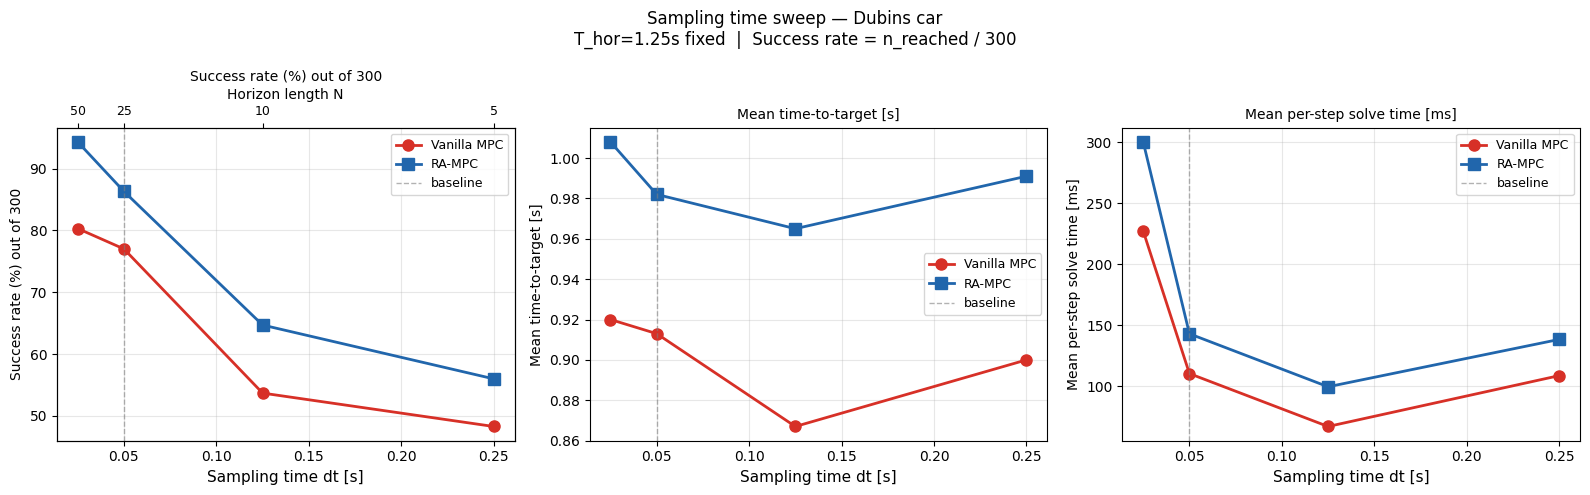

Saved fig_sampling_sweep_performance.png


In [17]:
# ── Performance vs sampling time ───────────────────────────────────────────────
methods  = ['Vanilla MPC', 'RA-MPC']
col_c    = {'Vanilla MPC': '#d73027', 'RA-MPC': '#2166ac'}
mark_c   = {'Vanilla MPC': 'o',       'RA-MPC': 's'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Sampling time sweep — Dubins car\n'
             f'T_hor={T_HOR_FIXED}s fixed  |  '
             f'Success rate = n_reached / {N_CANDIDATES}',
             fontsize=12)

for col, ylabel, ax_idx in [
    ('success_rate_300', f'Success rate (%) out of {N_CANDIDATES}', 0),
    ('mean_ttt',         'Mean time-to-target [s]',                 1),
    ('mean_step_ms',     'Mean per-step solve time [ms]',           2),
]:
    ax = axes[ax_idx]
    for method in methods:
        sub = summary[summary['method']==method].sort_values('dt_mpc')
        ax.plot(sub['dt_mpc'], sub[col],
                color=col_c[method], marker=mark_c[method],
                lw=2, ms=8, label=method)
    ax.axvline(0.05, color='gray', lw=1, ls='--', alpha=0.6, label='baseline')
    ax.set_xlabel('Sampling time dt [s]', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(ylabel, fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.tick_params(labelsize=10)

# Secondary x-axis with N_hor labels
ax2 = axes[0].twiny()
ax2.set_xlim(axes[0].get_xlim())
ax2.set_xticks([c['dt_mpc'] for c in CONFIGS])
ax2.set_xticklabels([str(c['N_hor']) for c in CONFIGS], fontsize=9)
ax2.set_xlabel('Horizon length N', fontsize=10)

plt.tight_layout()
plt.savefig('fig_sampling_sweep_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_sampling_sweep_performance.png')

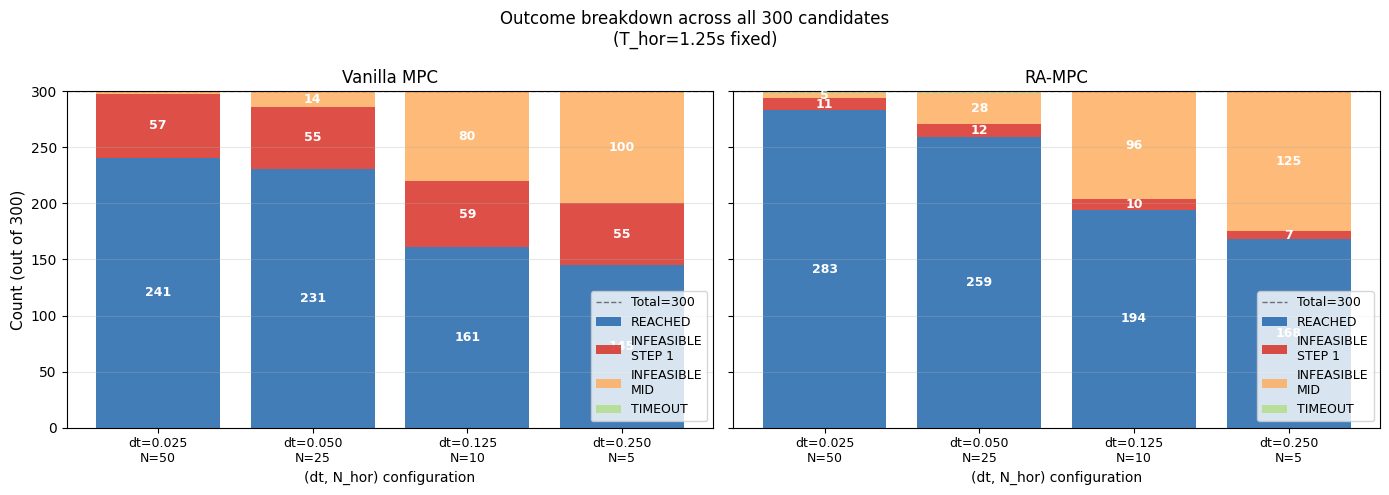

Saved fig_sampling_sweep_outcomes.png


In [18]:
# ── Stacked outcome bar chart — shows how 300 candidates decompose ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle(f'Outcome breakdown across all {N_CANDIDATES} candidates\n'
             f'(T_hor={T_HOR_FIXED}s fixed)', fontsize=12)

oc_cols   = ['n_reached', 'n_infeas_s1', 'n_infeas_mid', 'n_timeout']
oc_labels = ['REACHED', 'INFEASIBLE\nSTEP 1', 'INFEASIBLE\nMID', 'TIMEOUT']
oc_colors = ['#2166ac', '#d73027', '#fdae61', '#b2df8a']

for ax, method in zip(axes, methods):
    sub    = summary[summary['method']==method].sort_values('dt_mpc')
    x_pos  = np.arange(len(sub))
    bottom = np.zeros(len(sub))
    for col, lbl, color in zip(oc_cols, oc_labels, oc_colors):
        vals = sub[col].values.astype(float)
        bars = ax.bar(x_pos, vals, bottom=bottom, label=lbl, color=color, alpha=0.85)
        for xi, vi, bi in zip(x_pos, vals, bottom):
            if vi >= 5:
                ax.text(xi, bi + vi/2, str(int(vi)), ha='center', va='center',
                        fontsize=9, color='white', fontweight='bold')
        bottom += vals
    ax.axhline(N_CANDIDATES, color='black', lw=1, ls='--', alpha=0.5,
               label=f'Total={N_CANDIDATES}')
    ax.set_title(method, fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(
        [f'dt={c["dt_mpc"]:.3f}\nN={c["N_hor"]}' for c in CONFIGS], fontsize=9)
    ax.set_xlabel('(dt, N_hor) configuration', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')

axes[0].set_ylabel(f'Count (out of {N_CANDIDATES})', fontsize=11)
plt.tight_layout()
plt.savefig('fig_sampling_sweep_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_sampling_sweep_outcomes.png')

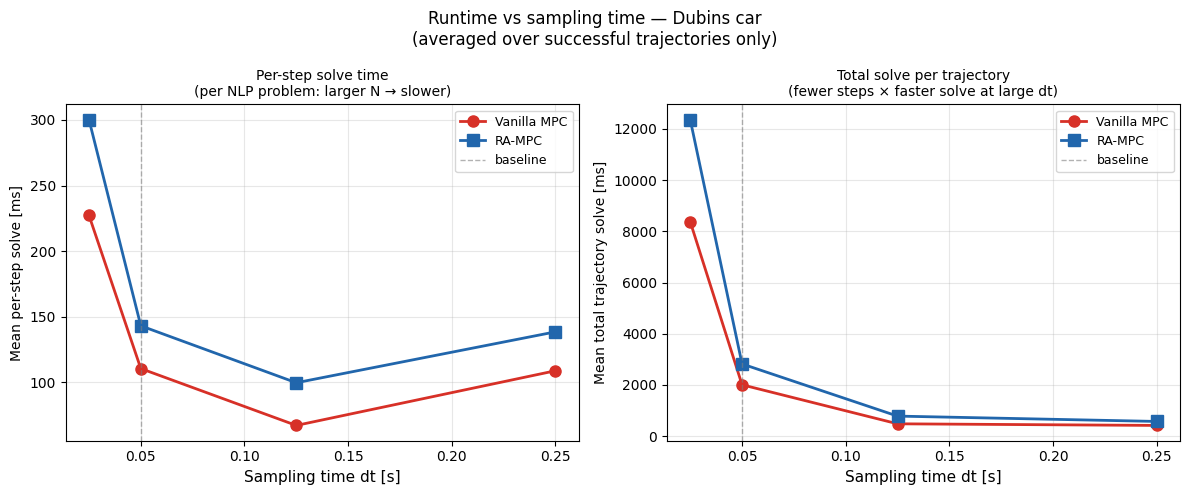

Saved fig_sampling_sweep_timing.png

=== Final summary (all rates out of 300) ===
     method  dt_mpc  N_hor  T_hor_actual  n_reached  success_rate_300  n_infeas_s1  n_infeas_mid  mean_ttt  mean_step_ms  total_ms
     RA-MPC   0.025     50          1.25        283              94.3           11             5     1.008        300.27   12360.8
     RA-MPC   0.050     25          1.25        259              86.3           12            28     0.982        142.95    2821.6
     RA-MPC   0.125     10          1.25        194              64.7           10            96     0.965         99.51     785.3
     RA-MPC   0.250      5          1.25        168              56.0            7           125     0.991        138.34     577.1
Vanilla MPC   0.025     50          1.25        241              80.3           57             2     0.920        227.22    8375.6
Vanilla MPC   0.050     25          1.25        231              77.0           55            14     0.913        110.32    2007.9
V

In [19]:
# ── Runtime vs sampling time ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Runtime vs sampling time — Dubins car\n'
             '(averaged over successful trajectories only)', fontsize=12)

for method in methods:
    sub = summary[summary['method']==method].sort_values('dt_mpc')
    axes[0].plot(sub['dt_mpc'], sub['mean_step_ms'],
                 color=col_c[method], marker=mark_c[method], lw=2, ms=8, label=method)
    axes[1].plot(sub['dt_mpc'], sub['total_ms'],
                 color=col_c[method], marker=mark_c[method], lw=2, ms=8, label=method)

for ax, ylabel, title in [
    (axes[0], 'Mean per-step solve [ms]',
              'Per-step solve time\n(per NLP problem: larger N → slower)'),
    (axes[1], 'Mean total trajectory solve [ms]',
              'Total solve per trajectory\n(fewer steps × faster solve at large dt)'),
]:
    ax.axvline(0.05, color='gray', lw=1, ls='--', alpha=0.6, label='baseline')
    ax.set_xlabel('Sampling time dt [s]', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('fig_sampling_sweep_timing.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_sampling_sweep_timing.png')

print(f'\n=== Final summary (all rates out of {N_CANDIDATES}) ===')
print(summary[['method','dt_mpc','N_hor','T_hor_actual',
               'n_reached','success_rate_300',
               'n_infeas_s1','n_infeas_mid','mean_ttt','mean_step_ms','total_ms']]
      .sort_values(['method','dt_mpc']).to_string(index=False))